# 特征工程基础 - 特征缩放和编码

本笔记本演示特征工程的基础操作，包括特征缩放、标准化和编码。

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

plt.rcParams['font.sans-serif'] = ['KaiTi']  # 楷体字
plt.rcParams['axes.unicode_minus'] = False
# 设置显示选项
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("特征工程基础库已导入")

特征工程基础库已导入


## 1. 特征缩放（Scaling）

In [2]:
# 创建示例数据
data = pd.DataFrame({
    '身高': [160, 175, 180, 165, 170],
    '体重': [50, 75, 80, 55, 70],
    '年龄': [20, 30, 25, 35, 28]
})

print("原始数据:")
print(data)
print()
print("数据统计信息:")
print(data.describe())

原始数据:
    身高  体重  年龄
0  160  50  20
1  175  75  30
2  180  80  25
3  165  55  35
4  170  70  28

数据统计信息:
               身高         体重        年龄
count    5.000000   5.000000   5.00000
mean   170.000000  66.000000  27.60000
std      7.905694  12.942179   5.59464
min    160.000000  50.000000  20.00000
25%    165.000000  55.000000  25.00000
50%    170.000000  70.000000  28.00000
75%    175.000000  75.000000  30.00000
max    180.000000  80.000000  35.00000


## 2. 标准化（Standardization）- StandardScaler

将特征转换为均值为0，标准差为1的分布：$z = \\frac{x - \\mu}{\\sigma}$

In [3]:
# 使用 StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# 转换为 DataFrame 以便查看
scaled_df = pd.DataFrame(scaled_data, columns=data.columns)

print("StandardScaler 标准化后的数据:")
print(scaled_df)
print()

print("标准化后的统计信息:")
print(scaled_df.describe())
print()

# 显示缩放参数
print(f"均值: {scaler.mean_}")
print(f"标准差: {scaler.scale_}")

StandardScaler 标准化后的数据:
         身高        体重        年龄
0 -1.414214 -1.382189 -1.518785
1  0.707107  0.777482  0.479616
2  1.414214  1.209416 -0.519584
3 -0.707107 -0.950255  1.478817
4  0.000000  0.345547  0.079936

标准化后的统计信息:
             身高            体重            年龄
count  5.000000  5.000000e+00  5.000000e+00
mean   0.000000  1.110223e-17 -3.025358e-16
std    1.118034  1.118034e+00  1.118034e+00
min   -1.414214 -1.382189e+00 -1.518785e+00
25%   -0.707107 -9.502553e-01 -5.195845e-01
50%    0.000000  3.455474e-01  7.993608e-02
75%    0.707107  7.774816e-01  4.796165e-01
max    1.414214  1.209416e+00  1.478817e+00

均值: [170.   66.   27.6]
标准差: [ 7.07106781 11.5758369   5.0039984 ]


## 3. 归一化（Normalization）- MinMaxScaler

将特征缩放到 [0, 1] 范围：$x_{norm} = \\frac{x - x_{min}}{x_{max} - x_{min}}$

In [4]:
# 使用 MinMaxScaler
minmax_scaler = MinMaxScaler()
minmax_scaled_data = minmax_scaler.fit_transform(data)

minmax_df = pd.DataFrame(minmax_scaled_data, columns=data.columns)

print("MinMaxScaler 归一化后的数据:")
print(minmax_df)
print()

print("归一化后的统计信息:")
print(minmax_df.describe())
print()

# 显示缩放参数
print(f"最小值: {minmax_scaler.data_min_}")
print(f"最大值: {minmax_scaler.data_max_}")

MinMaxScaler 归一化后的数据:
     身高        体重        年龄
0  0.00  0.000000  0.000000
1  0.75  0.833333  0.666667
2  1.00  1.000000  0.333333
3  0.25  0.166667  1.000000
4  0.50  0.666667  0.533333

归一化后的统计信息:
             身高        体重        年龄
count  5.000000  5.000000  5.000000
mean   0.500000  0.533333  0.506667
std    0.395285  0.431406  0.372976
min    0.000000  0.000000  0.000000
25%    0.250000  0.166667  0.333333
50%    0.500000  0.666667  0.533333
75%    0.750000  0.833333  0.666667
max    1.000000  1.000000  1.000000

最小值: [160.  50.  20.]
最大值: [180.  80.  35.]


## 4. 健壮缩放（Robust Scaling）- RobustScaler

对异常值更鲁棒，使用中位数和四分位数范围：$x_{robust} = \\frac{x - \\text{median}}{Q3 - Q1}$

In [10]:
# 创建包含异常值的数据
data_with_outlier = data.copy()
data_with_outlier.loc[2, '身高'] = 250  # 添加异常值

print("含异常值的数据:")
print(data_with_outlier)
print()

# 使用 RobustScaler
robust_scaler = RobustScaler()
robust_scaled_data = robust_scaler.fit_transform(data_with_outlier)

robust_df = pd.DataFrame(robust_scaled_data, columns=data_with_outlier.columns)

print("RobustScaler 缩放后的数据:")
print(robust_df)
print()

# 对比三种缩放方法
standard_scaled = StandardScaler().fit_transform(data_with_outlier)
standard_df = pd.DataFrame(standard_scaled, columns=data_with_outlier.columns)

print("StandardScaler（对异常值敏感）:")
print(standard_df)

含异常值的数据:
    身高  体重  年龄
0  160  50  20
1  175  75  30
2  250  80  25
3  165  55  35
4  170  70  28

RobustScaler 缩放后的数据:
    身高    体重   年龄
0 -1.0 -1.00 -1.6
1  0.5  0.25  0.4
2  8.0  0.50 -0.6
3 -0.5 -0.75  1.4
4  0.0  0.00  0.0

StandardScaler（对异常值敏感）:
         身高        体重        年龄
0 -0.719066 -1.382189 -1.518785
1 -0.269650  0.777482  0.479616
2  1.977431  1.209416 -0.519584
3 -0.569260 -0.950255  1.478817
4 -0.419455  0.345547  0.079936


## 5. 类别特征编码 - Label Encoding

将类别特征编码为整数（0, 1, 2, ...）

In [5]:
# 创建包含类别特征的数据
data_cat = pd.DataFrame({
    '城市': ['北京', '上海', '深圳', '北京', '杭州'],
    '性别': ['男', '女', '男', '女', '男'],
    '年龄': [25, 30, 28, 35, 32]
})

print("原始数据:")
print(data_cat)
print()

# Label Encoding
le_city = LabelEncoder()
le_gender = LabelEncoder()

data_encoded = data_cat.copy()
data_encoded['城市'] = le_city.fit_transform(data_cat['城市'])
data_encoded['性别'] = le_gender.fit_transform(data_cat['性别'])

print("Label Encoding 后的数据:")
print(data_encoded)
print()

# 显示映射关系
print("城市映射:")
for i, city in enumerate(le_city.classes_):
    print(f"  {city}: {i}")
print()

print("性别映射:")
for i, gender in enumerate(le_gender.classes_):
    print(f"  {gender}: {i}")

原始数据:
   城市 性别  年龄
0  北京  男  25
1  上海  女  30
2  深圳  男  28
3  北京  女  35
4  杭州  男  32

Label Encoding 后的数据:
   城市  性别  年龄
0   1   1  25
1   0   0  30
2   3   1  28
3   1   0  35
4   2   1  32

城市映射:
  上海: 0
  北京: 1
  杭州: 2
  深圳: 3

性别映射:
  女: 0
  男: 1


## 6. One-Hot Encoding

将类别特征转换为多个二进制特征（更适合树模型和神经网络）

In [8]:
# 使用 pd.get_dummies 实现 One-Hot Encoding
data_onehot = pd.get_dummies(data_cat, columns=['城市', '性别'], drop_first=False)

print("One-Hot Encoding 后的数据:")
print(data_onehot)
print()
print(f"原始列数: {data_cat.shape[1]}, One-Hot 后列数: {data_onehot.shape[1]}")

One-Hot Encoding 后的数据:
   年龄  城市_上海  城市_北京  城市_杭州  城市_深圳   性别_女   性别_男
0  25  False   True  False  False  False   True
1  30   True  False  False  False   True  False
2  28  False  False  False   True  False   True
3  35  False   True  False  False   True  False
4  32  False  False   True  False  False   True

原始列数: 3, One-Hot 后列数: 7


In [7]:
# 使用 drop_first=True 避免多重共线性
print("\nOne-Hot Encoding (drop_first=True):")
data_onehot_drop = pd.get_dummies(data_cat, columns=['城市', '性别'], drop_first=True)
print(data_onehot_drop)
print()
print(f"列数: {data_onehot_drop.shape[1]}")


One-Hot Encoding (drop_first=True):
   年龄  城市_北京  城市_杭州  城市_深圳   性别_男
0  25   True  False  False   True
1  30  False  False  False  False
2  28  False  False   True   True
3  35   True  False  False  False
4  32  False   True  False   True

列数: 5


## 7. 可视化对比

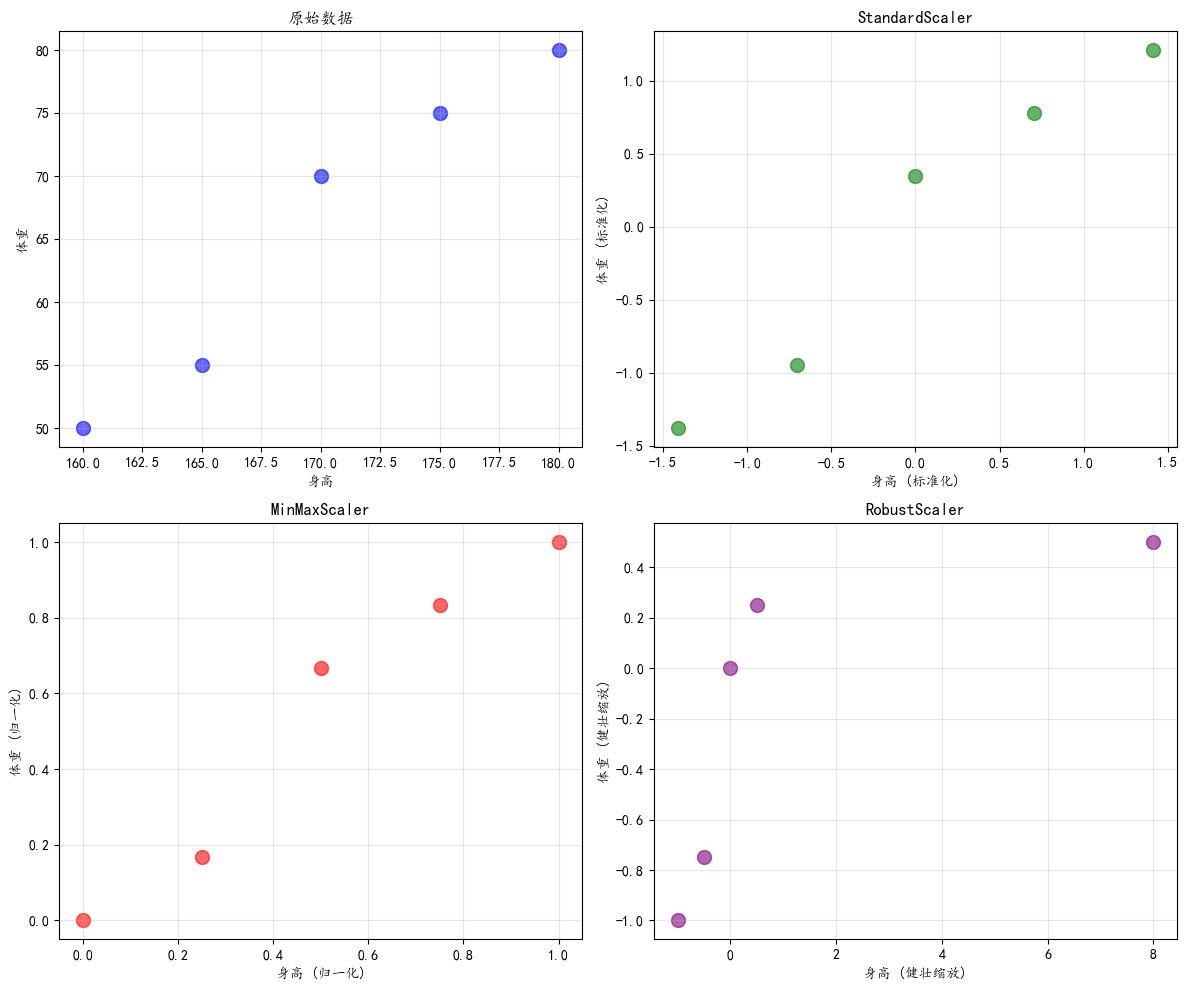

In [13]:
# 绘制三种缩放方法的对比
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 原始数据
axes[0, 0].scatter(data['身高'], data['体重'], alpha=0.6, s=100, color='blue')
axes[0, 0].set_xlabel('身高')
axes[0, 0].set_ylabel('体重')
axes[0, 0].set_title('原始数据')
axes[0, 0].grid(True, alpha=0.3)

# StandardScaler
axes[0, 1].scatter(scaled_df['身高'], scaled_df['体重'], alpha=0.6, s=100, color='green')
axes[0, 1].set_xlabel('身高 (标准化)')
axes[0, 1].set_ylabel('体重 (标准化)')
axes[0, 1].set_title('StandardScaler')
axes[0, 1].grid(True, alpha=0.3)

# MinMaxScaler
axes[1, 0].scatter(minmax_df['身高'], minmax_df['体重'], alpha=0.6, s=100, color='red')
axes[1, 0].set_xlabel('身高 (归一化)')
axes[1, 0].set_ylabel('体重 (归一化)')
axes[1, 0].set_title('MinMaxScaler')
axes[1, 0].grid(True, alpha=0.3)

# RobustScaler
axes[1, 1].scatter(robust_df['身高'], robust_df['体重'], alpha=0.6, s=100, color='purple')
axes[1, 1].set_xlabel('身高 (健壮缩放)')
axes[1, 1].set_ylabel('体重 (健壮缩放)')
axes[1, 1].set_title('RobustScaler')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 绘制直方图对比
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(data['身高'], bins=5, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('原始身高分布')
axes[0].set_xlabel('身高')
axes[0].set_ylabel('频率')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].hist(scaled_df['身高'], bins=5, alpha=0.7, color='green', edgecolor='black')
axes[1].set_title('标准化后的身高分布')
axes[1].set_xlabel('身高 (标准化)')
axes[1].set_ylabel('频率')
axes[1].grid(True, alpha=0.3, axis='y')

axes[2].hist(minmax_df['身高'], bins=5, alpha=0.7, color='red', edgecolor='black')
axes[2].set_title('归一化后的身高分布')
axes[2].set_xlabel('身高 (归一化)')
axes[2].set_ylabel('频率')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()